Este fragmento de Aurélien Géron es la esencia de cómo un árbol de decisión toma decisiones basándose en "reglas de división" geométricas y cómo mide la pureza de sus datos.



# Cómo hacer Predicciones



Veamos cómo el árbol representado en la Figura 5-1 toma decisiones. 

Supón que encuentras una flor Iris y quieres clasificarla basándote en sus pétalos. 

Comienzas en el **nodo raíz** (profundidad 0, en la parte superior): este nodo pregunta si la longitud del pétalo de la flor es menor que 2.45 cm. 

Si lo es, te desplazas hacia el nodo hijo izquierdo de la raíz (profundidad 1, izquierda). 

En este caso, es un **nodo hoja** (es decir, no tiene nodos hijos), por lo que no hace más preguntas: simplemente miras la clase predicha para ese nodo y el árbol de decisión predice que tu flor es una *Iris setosa* (`class=setosa`).



Ahora supón que encuentras otra flor, y esta vez la longitud del pétalo es mayor que 2.45 cm. 

Comienzas de nuevo en la raíz, pero ahora te desplazas hacia su nodo hijo derecho (profundidad 1, derecha). 

Este no es un nodo hoja, es un **nodo de división**, por lo que hace otra pregunta: ¿el ancho del pétalo es menor que 1.75 cm? Si lo es, entonces es muy probable que tu flor sea una *Iris versicolor* (profundidad 2, izquierda). 

Si no, es probable que sea una *Iris virginica* (profundidad 2, derecha). 

Es realmente así de simple.



> **Nota:** Una de las muchas cualidades de los árboles de decisión es que **requieren muy poca preparación de datos**. 

De hecho, no requieren en absoluto escalado ni centrado de características (*feature scaling*).



El atributo `samples` (muestras) de un nodo cuenta a cuántas instancias de entrenamiento se aplica. 

Por ejemplo, 100 instancias de entrenamiento tienen una longitud de pétalo mayor que 2.45 cm (profundidad 1, derecha), y de esas 100, 54 tienen un ancho de pétalo menor que 1.75 cm (profundidad 2, izquierda).



El atributo `value` (valor) de un nodo te dice a cuántas instancias de entrenamiento de cada clase se aplica dicho nodo: por ejemplo, el nodo inferior derecho se aplica a 0 *Iris setosa*, 1 *Iris versicolor* y 45 *Iris virginica*.



Finalmente, el atributo `gini` de un nodo mide su **impureza de Gini**: un nodo es "puro" ($Gini = 0$) si todas las instancias de entrenamiento a las que se aplica pertenecen a la misma clase. 

Por ejemplo, dado que el nodo izquierdo de profundidad 1 se aplica solo a instancias de entrenamiento de *Iris setosa*, su impureza de Gini es 0. 

Por el contrario, los otros nodos se aplican a instancias de múltiples clases, por lo que son "impuros".

La Ecuación 5-1 muestra cómo el algoritmo de entrenamiento calcula la impureza de Gini $G_i$ del $i$-ésimo nodo. 

Cuantas más clases haya y más mezcladas estén, mayor será la impureza. 

Por ejemplo, el nodo izquierdo de profundidad 2 tiene una impureza de Gini igual a:

$$G = 1 - \left(\frac{0}{54}\right)^2 - \left(\frac{49}{54}\right)^2 - \left(\frac{5}{54}\right)^2 \approx 0.168$$



#### Ecuación 5-1. Impureza de Gini

$$G_i = 1 - \sum_{k=1}^{n} {p_{i,k}}^2$$

En esta ecuación:

* $G_i$ es la impureza de Gini del $i$-ésimo nodo.
* $p_{i,k}$ es la proporción de instancias de la clase $k$ entre las instancias de entrenamiento en el $i$-ésimo nodo (es decir: $\frac{\text{muestras de la clase } k}{\text{muestras totales en el nodo}}$).



> **Nota:** Scikit-Learn utiliza el **algoritmo CART**, el cual produce **únicamente árboles binarios**, lo que significa que los nodos de división siempre tienen exactamente dos hijos (es decir, las preguntas solo tienen respuestas de sí o no). Sin embargo, otros algoritmos como ID3 pueden producir árboles de decisión con nodos que tienen más de dos hijos.



La Figura 5-2 muestra las fronteras de decisión (*decision boundaries*) de este árbol. 

La línea gruesa vertical representa la frontera del nodo raíz (profundidad 0): longitud del pétalo = 2.45 cm. 

Dado que el área de la izquierda es pura (solo *Iris setosa*), no se puede dividir más. 

Sin embargo, el área de la derecha es impura, por lo que el nodo derecho de profundidad 1 la divide en el ancho del pétalo = 1.75 cm (representado por una línea discontinua). 

Dado que el hiperparámetro `max_depth` se configuró en 2, el árbol se detiene ahí. Si configuraras `max_depth=3`, los dos nodos de profundidad 2 agregarían cada uno otra frontera de decisión.



La estructura del árbol, incluyendo toda la información visual, está disponible a través del atributo `tree_` del clasificador. 

Puedes escribir `help(tree_clf.tree_)` en tu consola para ver los detalles técnicos.

---



## 2. Scripts de Python para Ejemplificar y Visualizar

Para que puedas ver exactamente lo que describe el libro, ejecuta los siguientes scripts en tu entorno local (o en un Jupyter Notebook).



### Script 1: Visualización Completa del Árbol (Figura 5-1 Moderna)

Este script genera la estructura del árbol con sus valores de Gini, muestras y condiciones sin requerir herramientas externas.



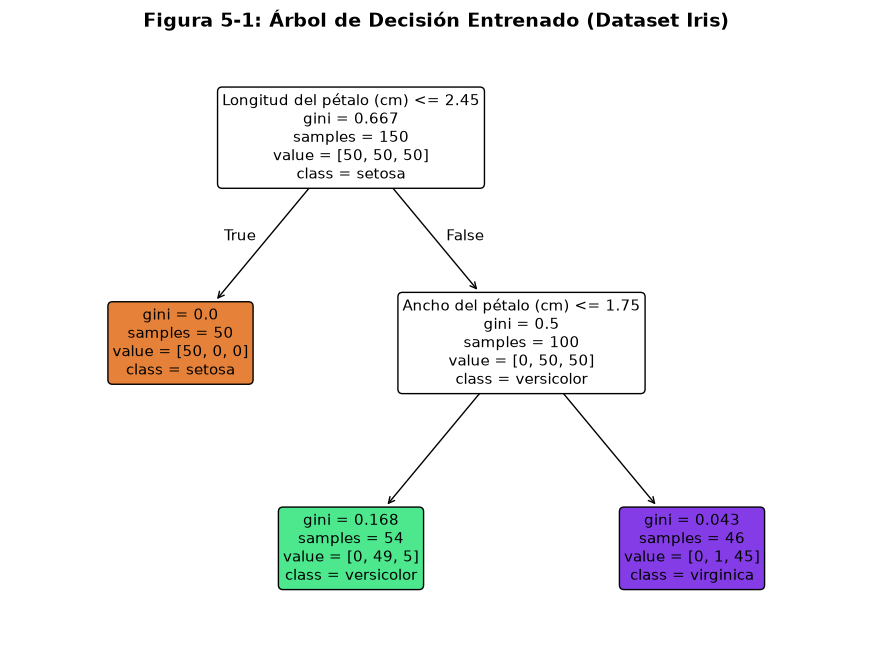

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Cargar datos (usando solo longitud y ancho del pétalo)
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

# 2. Entrenar el modelo con profundidad máxima de 2
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

# 3. Graficar el árbol de decisión estilizado
plt.figure(figsize=(11, 8), dpi=100)
plot_tree(
    tree_clf,
    feature_names=["Longitud del pétalo (cm)", "Ancho del pétalo (cm)"],
    class_names=list(iris.target_names),
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title("Figura 5-1: Árbol de Decisión Entrenado (Dataset Iris)", fontsize=14, fontweight='bold')
plt.savefig(r"C:\Users\marco\Downloads\arbol_decision_entrenado.png")
plt.show()



## Script 2: Fronteras de Decisión en el Espacio de Características (Figura 5-2)

Este script dibuja las regiones que el árbol corta geométricamente para separar las tres especies de flores.



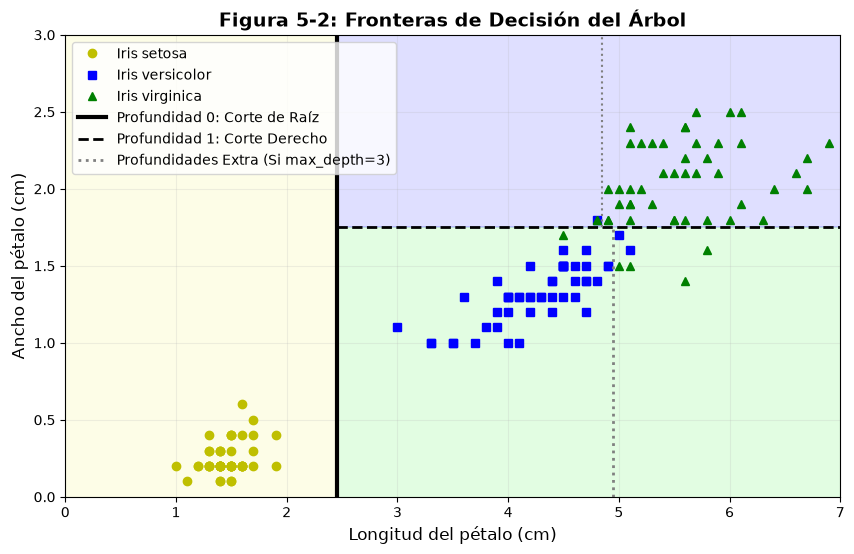

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

# Re-entrenar de manera idéntica
iris = load_iris()
X = iris.data[:, [2, 3]] # Longitud y ancho del pétalo
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

# Configurar el fondo para el mapa de colores (Fronteras de decisión)
def plot_decision_boundary(clf, X, y, axes=[0, 7, 0, 3]):
    x1s = np.linspace(axes[0], axes[1], 500)
    x2s = np.linspace(axes[2], axes[3], 500)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    
    # Colores para las zonas
    custom_cmap = ListedColormap(['#fafab0','#a0faa0','#9898ff'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    
    # Dibujar los puntos del dataset original
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
    plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris virginica")
    plt.axis(axes)

plt.figure(figsize=(10, 6))
plot_decision_boundary(tree_clf, X, y)

# ---- DIBUJAR LAS LÍNEAS DE CORTE QUE DETALLA EL TEXTO ----
# División del nodo raíz (Profundidad 0) en longitud = 2.45
plt.axvline(x=2.45, color="black", linestyle="-", linewidth=3, label="Profundidad 0: Corte de Raíz")

# División de profundidad 1 en ancho = 1.75
plt.axhline(y=1.75, xmin=2.45/7, xmax=1, color="black", linestyle="--", linewidth=2, label="Profundidad 1: Corte Derecho")

# Simulando líneas si max_depth fuera 3 (líneas punteadas mencionadas en el texto)
plt.axvline(x=4.95, ymin=0, ymax=1.75/3, color="gray", linestyle=":", linewidth=2, label="Profundidades Extra (Si max_depth=3)")
plt.axvline(x=4.85, ymin=1.75/3, ymax=1, color="gray", linestyle=":")

# Ajustes de etiquetas
plt.xlabel("Longitud del pétalo (cm)", fontsize=12)
plt.ylabel("Ancho del pétalo (cm)", fontsize=12)
plt.title("Figura 5-2: Fronteras de Decisión del Árbol", fontsize=14, fontweight='bold')
plt.legend(loc="upper left", fontsize=10)
plt.grid(True, alpha=0.2)
plt.savefig(r"C:\Users\marco\Downloads\fronteras_decision_arbol.png", dpi=300)
plt.show()



# ¿Qué notar en las gráficas?

* Al correr el segundo script notarás cómo el área a la izquierda de la línea negra sólida ($x < 2.45$) solo contiene círculos amarillos (*setosa*), por lo que es perfectamente pura ($Gini = 0$).


* La zona de la derecha queda dividida de forma horizontal en el umbral $1.75$. Los cuadrados azules (*versicolor*) quedan mayoritariamente abajo y los triángulos verdes (*virginica*) arriba.